# Euclidean Alignment + CSP + LDA Cross-Subject Motor Imagery Benchmark

## Context

This notebook extends the baseline CSP + LDA experiment with **Euclidean Alignment (EA)** before CSP.

**Model:** Euclidean Alignment + CSP (Common Spatial Patterns) + LDA (Linear Discriminant Analysis)  
**Evaluation:** Cross-subject (train on all subjects except one, test on held-out subject)  
**Dataset:** BNCI2014_001 (9 subjects, 2 sessions, left vs right hand motor imagery)  

**Why this matters:**
Cross-subject generalization is difficult in BCI because EEG distributions shift across individuals. Euclidean Alignment is intended to reduce this mismatch by aligning covariance structure before feature extraction.

# 1. Setup

## 1.1. Imports

In [1]:
# Reproducible setup
import warnings
warnings.filterwarnings('ignore')

import builtins
from datetime import datetime
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# MOABB imports
from moabb.datasets import BNCI2014_001
from moabb.paradigms import LeftRightImagery
from moabb.evaluations import CrossSubjectEvaluation

# MNE for CSP
from mne.decoding import CSP

# scikit-learn imports
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## 1.2. Create artifact directory

In [2]:
# Fixed artifact directory (overwrite existing files on save)
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
ARTIFACT_DIR = BASE_DIR / 'artifacts' / '03_ea_csp_lda'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Artifact directory: {ARTIFACT_DIR}')

Artifact directory: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_ea_csp_lda


## 1.3. Initialize Logger

In [3]:
# Reset log file each time this setup cell is run
LOG_PATH = ARTIFACT_DIR / 'run.log'
if '_LOG_FILE_HANDLE' in globals() and _LOG_FILE_HANDLE and not _LOG_FILE_HANDLE.closed:
    _LOG_FILE_HANDLE.close()
_LOG_FILE_HANDLE = open(LOG_PATH, 'w', buffering=1)

def _timestamped_print(*args, **kwargs):
    sep = kwargs.pop('sep', ' ')
    end = kwargs.pop('end', '\n')
    flush = kwargs.pop('flush', False)
    file = kwargs.pop('file', None)

    message = sep.join(str(arg) for arg in args)

    leading_newlines = len(message) - len(message.lstrip('\n'))
    message_body = message[leading_newlines:]

    def _write_target(text):
        if file is None:
            sys.__stdout__.write(text)
            if flush:
                sys.__stdout__.flush()
        else:
            file.write(text)
            if flush and hasattr(file, 'flush'):
                file.flush()

    if leading_newlines > 0:
        blanks = '\n' * leading_newlines
        _write_target(blanks)
        _LOG_FILE_HANDLE.write(blanks)

    if message_body:
        ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        stamped = f'[{ts}] {message_body}'
        _write_target(stamped + end)
        _LOG_FILE_HANDLE.write(stamped + end)
    else:
        _write_target(end)
        _LOG_FILE_HANDLE.write(end)

    if flush:
        _LOG_FILE_HANDLE.flush()

builtins.print = _timestamped_print

print(f'Logging to: {LOG_PATH}')

[2026-04-13 19:44:04] Logging to: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_ea_csp_lda/run.log


## 1.4. Save Artifacts

In [4]:
def save_plot(filename):
    path = ARTIFACT_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved plot: {path}')

def save_table(df, filename):
    path = ARTIFACT_DIR / filename
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')

def save_json(obj, filename):
    path = ARTIFACT_DIR / filename
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2)
    print(f'Saved json: {path}')

# 2. Data

## 2.1. Dataset Setup

In [5]:
# Instantiate dataset and paradigm
dataset = BNCI2014_001()
paradigm = LeftRightImagery()

print('Dataset and paradigm initialized.')
print(f'Dataset: {dataset.__class__.__name__}')
print(f'Paradigm: {paradigm.__class__.__name__}')

[2026-04-13 19:44:04] Dataset and paradigm initialized.
[2026-04-13 19:44:04] Dataset: BNCI2014_001
[2026-04-13 19:44:04] Paradigm: LeftRightImagery


## 2.2. Dataset Metadata Inspection

In [6]:
print('=' * 60)
print('DATASET INFORMATION')
print('=' * 60)
print(f'Number of subjects: {len(dataset.subject_list)}')
print(f'Subject IDs: {dataset.subject_list}')
print(f'Number of sessions: {dataset.n_sessions}')
print(f'Event IDs (all classes): {dataset.event_id}')

[2026-04-13 19:44:04] ============================================================
[2026-04-13 19:44:04] DATASET INFORMATION
[2026-04-13 19:44:04] ============================================================
[2026-04-13 19:44:04] Number of subjects: 9
[2026-04-13 19:44:04] Subject IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9]
[2026-04-13 19:44:04] Number of sessions: 2
[2026-04-13 19:44:04] Event IDs (all classes): {'left_hand': 1, 'right_hand': 2, 'feet': 3, 'tongue': 4}


In [7]:
print('\n' + '=' * 60)
print('PARADIGM INFORMATION')
print('=' * 60)

# Paradigm details
print(f'Frequency filters: {paradigm.filters}')
print(f'Paradigm events (left/right only): {paradigm.events}')


[2026-04-13 19:44:04] ============================================================
[2026-04-13 19:44:04] PARADIGM INFORMATION
[2026-04-13 19:44:04] ============================================================
[2026-04-13 19:44:04] Frequency filters: [[8, 32]]
[2026-04-13 19:44:04] Paradigm events (left/right only): ['left_hand', 'right_hand']


# 3. EA + CSP + LDA Pipeline Definition

**CSP + LDA remains the core classifier family.**  
Euclidean Alignment is added before CSP to reduce cross-subject covariance mismatch.

**Euclidean Alignment (EA):**  
EA computes a reference covariance from training trials and transforms each trial with the inverse square root of that covariance.

## 3.1. Euclidean Alignment Definition

In [8]:
class EuclideanAlignment(BaseEstimator, TransformerMixin):
    """Align EEG trials by whitening with training-set average covariance."""

    def __init__(self, epsilon=1e-10):
        self.epsilon = epsilon

    def _trial_cov(self, X_trial):
        # X_trial shape: (n_channels, n_times)
        X_centered = X_trial - X_trial.mean(axis=1, keepdims=True)
        n_times = X_centered.shape[1]
        denom = max(n_times - 1, 1)
        cov = (X_centered @ X_centered.T) / denom
        return cov

    def fit(self, X, y=None):
        # X shape: (n_trials, n_channels, n_times)
        covs = np.array([self._trial_cov(trial) for trial in X])
        ref_cov = covs.mean(axis=0)

        eigvals, eigvecs = np.linalg.eigh(ref_cov)
        eigvals = np.clip(eigvals, self.epsilon, None)
        inv_sqrt = eigvecs @ np.diag(eigvals ** -0.5) @ eigvecs.T

        self.ref_cov_ = ref_cov
        self.inv_sqrt_ref_cov_ = inv_sqrt
        return self

    def transform(self, X):
        if not hasattr(self, 'inv_sqrt_ref_cov_'):
            raise RuntimeError('EuclideanAlignment must be fitted before transform.')

        # Left-multiply each trial with inverse sqrt reference covariance
        X_aligned = np.array([self.inv_sqrt_ref_cov_ @ trial for trial in X])
        return X_aligned

## 3.2. Pipeline Definition

In [9]:
# Build the improved pipeline
pipeline = make_pipeline(
    EuclideanAlignment(epsilon=1e-10),
    CSP(n_components=8, reg=None, log=True, norm_trace=False),
    LDA(solver='lsqr', shrinkage='auto')
)

# Create a dictionary for MOABB evaluation
pipelines = {'EA+CSP+LDA': pipeline}

print('Improved pipeline created:')
print(pipeline)

[2026-04-13 19:44:04] Improved pipeline created:
[2026-04-13 19:44:04] Pipeline(steps=[('euclideanalignment', EuclideanAlignment()),
                ('csp', CSP(log=True, n_components=8)),
                ('lineardiscriminantanalysis',
                 LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))])


## 3.3. Cross-Subject Evaluation Setup

In [10]:
# Create cross-subject evaluation object
evaluation = CrossSubjectEvaluation(
    paradigm=paradigm,
    datasets=[dataset],
    overwrite=False
)

print('Cross-subject evaluation configured.')

[2026-04-13 19:44:04] Cross-subject evaluation configured.


## 3.4. Run EA + CSP + LDA Benchmark

In [11]:
# Run the evaluation
print('Running cross-subject evaluation...')

results = evaluation.process(pipelines)

print('\nEvaluation complete!')
print(f'Results shape: {results.shape}')
print(f'Results columns: {list(results.columns)}')

save_table(results, 'results.csv')

[2026-04-13 19:44:04] Running cross-subject evaluation...


BNCI2014-001-CrossSubject:   0%|          | 0/9 [00:00<?, ?it/s]

Computing rank from data with rank=None
    Using tolerance 7.4 (2.2e-16 eps * 22 dim * 1.5e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


BNCI2014-001-CrossSubject:  11%|█         | 1/9 [00:02<00:17,  2.19s/it]

Computing rank from data with rank=None
    Using tolerance 7.4 (2.2e-16 eps * 22 dim * 1.5e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


...

Computing rank from data with rank=None
    Using tolerance 7.4 (2.2e-16 eps * 22 dim * 1.5e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


BNCI2014-001-CrossSubject:  89%|████████▉ | 8/9 [00:13<00:01,  1.67s/it]

Computing rank from data with rank=None
    Using tolerance 7.4 (2.2e-16 eps * 22 dim * 1.5e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


BNCI2014-001-CrossSubject: 100%|██████████| 9/9 [00:15<00:00,  1.71s/it]



[2026-04-13 19:44:31] Evaluation complete!
[2026-04-13 19:44:31] Results shape: (18, 9)
[2026-04-13 19:44:31] Results columns: ['score', 'time', 'samples', 'subject', 'session', 'channels', 'n_sessions', 'dataset', 'pipeline']
[2026-04-13 19:44:31] Saved table: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_ea_csp_lda/results.csv


## 3.5. Inspect Results

In [12]:
# Display results table
print('\n' + '=' * 60)
print('Results:')
print('=' * 60)
print(f'{results}')


[2026-04-13 19:44:32] ============================================================
[2026-04-13 19:44:32] Results:
[2026-04-13 19:44:32] ============================================================
[2026-04-13 19:44:32]        score      time  samples subject session  channels  n_sessions       dataset    pipeline
0   0.910494  2.117745   2304.0       1  0train        22           2  BNCI2014-001  EA+CSP+LDA
1   0.936535  2.117745   2304.0       1   1test        22           2  BNCI2014-001  EA+CSP+LDA
2   0.570602  1.658851   2304.0       2  0train        22           2  BNCI2014-001  EA+CSP+LDA
3   0.557870  1.658851   2304.0       2   1test        22           2  BNCI2014-001  EA+CSP+LDA
4   0.983410  1.599609   2304.0       3  0train        22           2  BNCI2014-001  EA+CSP+LDA
5   0.976852  1.599609   2304.0       3   1test        22           2  BNCI2014-001  EA+CSP+LDA
6   0.750000  1.592350   2304.0       4  0train        22           2  BNCI2014-001  EA+CSP+LDA
7   0.809221

## 3.6. Summary Statistics

In [13]:
# Summary statistics
print('\n' + '=' * 60)
print('RESULTS SUMMARY')
print('=' * 60)

summary_dict = {
    'mean_score': float(results['score'].mean()),
    'std_score': float(results['score'].std()),
    'min_score': float(results['score'].min()),
    'max_score': float(results['score'].max())
}

print(f"Mean score: {summary_dict['mean_score']:.4f}")
print(f"Std score: {summary_dict['std_score']:.4f}")
print(f"Min score: {summary_dict['min_score']:.4f}")
print(f"Max score: {summary_dict['max_score']:.4f}")

summary_df = pd.DataFrame([summary_dict])
save_table(summary_df, 'summary_metrics.csv')
save_json(summary_dict, 'summary_metrics.json')


[2026-04-13 19:44:32] ============================================================
[2026-04-13 19:44:32] RESULTS SUMMARY
[2026-04-13 19:44:32] ============================================================
[2026-04-13 19:44:32] Mean score: 0.7719
[2026-04-13 19:44:32] Std score: 0.1625
[2026-04-13 19:44:32] Min score: 0.5089
[2026-04-13 19:44:32] Max score: 0.9907
[2026-04-13 19:44:32] Saved table: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_ea_csp_lda/summary_metrics.csv
[2026-04-13 19:44:32] Saved json: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_ea_csp_lda/summary_metrics.json


# 4. Per-Subject Analysis

## 4.1. Get Subject Performance

In [14]:
# Compute per-subject scores
per_subject_scores = results.groupby('subject')['score'].mean().sort_values()

print('=' * 60)
print('PER-SUBJECT PERFORMANCE (sorted from worst to best)')
print('=' * 60)
print(per_subject_scores)

print(f'\nBest performing subject: {per_subject_scores.idxmax()} ({per_subject_scores.max():.4f})')
print(f'Worst performing subject: {per_subject_scores.idxmin()} ({per_subject_scores.min():.4f})')

per_subject_df = per_subject_scores.reset_index()
save_table(per_subject_df, 'per_subject_scores.csv')

[2026-04-13 19:44:32] ============================================================
[2026-04-13 19:44:32] PER-SUBJECT PERFORMANCE (sorted from worst to best)
[2026-04-13 19:44:32] ============================================================
[2026-04-13 19:44:32] subject
2    0.564236
5    0.564718
6    0.666184
7    0.676697
4    0.779610
9    0.807292
1    0.923515
3    0.980131
8    0.984857
Name: score, dtype: float32

[2026-04-13 19:44:32] Best performing subject: 8 (0.9849)
[2026-04-13 19:44:32] Worst performing subject: 2 (0.5642)
[2026-04-13 19:44:32] Saved table: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_ea_csp_lda/per_subject_scores.csv


## 4.2. Visualize Per-Subject Performance

[2026-04-13 19:44:32] Saved plot: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_ea_csp_lda/per_subject_accuracy_bar.png


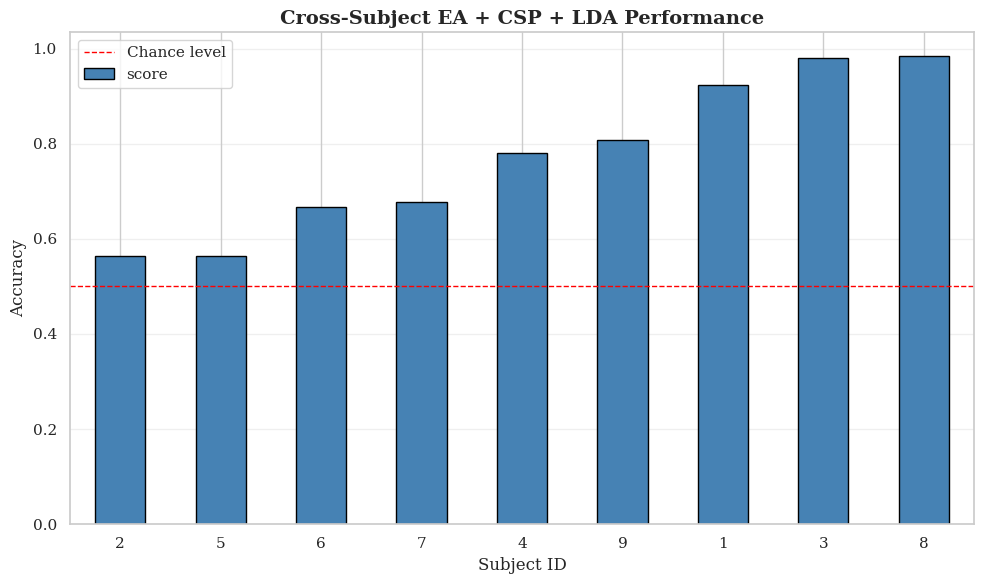

[2026-04-13 19:44:32] Saved plot: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_ea_csp_lda/performance_distribution_boxplot.png


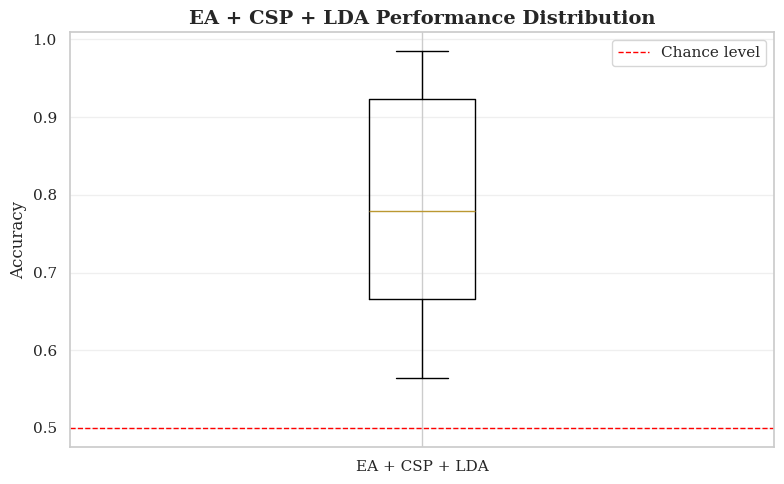

In [15]:
plt.figure(figsize=(10, 6))
per_subject_scores.plot(kind='bar', color='steelblue', edgecolor='black')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Chance level')
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Cross-Subject EA + CSP + LDA Performance', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('per_subject_accuracy_bar.png')
plt.show()

# Summary statistics plot
plt.figure(figsize=(8, 5))
plt.boxplot([per_subject_scores.values], labels=['EA + CSP + LDA'])
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Chance level')
plt.ylabel('Accuracy', fontsize=12)
plt.title('EA + CSP + LDA Performance Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('performance_distribution_boxplot.png')
plt.show()

## 4.3. Identify Low-Performing Subjects

In [16]:
# Rank subjects from worst to best
print('=' * 60)
print('LOW-PERFORMING SUBJECTS (candidates for comparison)')
print('=' * 60)

# Show bottom 3 subjects
bottom_subjects = per_subject_scores.head(3)
print('Bottom 3 subjects:')
for subject, score in bottom_subjects.items():
    print(f'  Subject {subject}: {score:.4f}')

# Compute how many subjects are below median
median_score = per_subject_scores.median()
below_median = (per_subject_scores < median_score).sum()

print(f'Median score: {median_score:.4f}')
print(f'Subjects below median: {below_median}/{len(per_subject_scores)}')
print('These subjects will be carried forward into the comparison notebook.')

[2026-04-13 19:44:32] ============================================================
[2026-04-13 19:44:32] LOW-PERFORMING SUBJECTS (candidates for comparison)
[2026-04-13 19:44:32] ============================================================
[2026-04-13 19:44:32] Bottom 3 subjects:
[2026-04-13 19:44:32]   Subject 2: 0.5642
[2026-04-13 19:44:32]   Subject 5: 0.5647
[2026-04-13 19:44:32]   Subject 6: 0.6662
[2026-04-13 19:44:32] Median score: 0.7796
[2026-04-13 19:44:32] Subjects below median: 4/9
[2026-04-13 19:44:32] These subjects will be carried forward into the comparison notebook.


## Interpretation and Next Steps

### What Was Learned

This improved experiment reveals:

1. **Overall cross-subject performance:** EA + CSP + LDA provides a direct aligned extension of the baseline pipeline.

2. **Subject variability:** Performance may still vary by subject, which remains a key challenge in practical BCI deployment.

3. **Impact of alignment:** Any gains, especially in lower-performing subjects, indicate that alignment can reduce subject mismatch before CSP feature extraction.

### Why This Matters

If weak subjects remain weak, this supports additional alignment or adaptation methods. If several weak subjects improve, Euclidean Alignment is a useful low-complexity step for cross-subject robustness.

### Next Step

Compare this notebook directly against the baseline in 02_baseline_csp_lda.ipynb, with special focus on the lowest-performing subjects in both runs.